In [3]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def snot(N=None, target=0):
    if N is not None:
        return gate_expand_1toN(snot(), N, target)
    else:
        return 1 / np.sqrt(2.0) * Qobj([[1, 1],
                                        [1, -1]])

In [ ]:
def Vj(lmbda,j,n): 
    qubit_pauli = tensor([identity(2)]*(j-1) + [sigmay()] + [identity(2)]*(n-j))
    # print(qubit_pauli)
    return tensor(qubit_pauli, (1j*np.pi)/(2**(j+1)*lmbda)*(destroy(cutoff) + create(cutoff))/np.sqrt(2.0)).expm()

def Wj(lmbda,j,n):
    qubit_pauli = tensor([identity(2)]*(j-1) + [sigmax()] + [identity(2)]*(n-j))
    if j == n:      
        disp_amount = -lmbda*2**(j-1)
    else:
        disp_amount = lmbda*2**(j-1)
    # print(qubit_pauli)
    return tensor(qubit_pauli, disp_amount*(destroy(cutoff) - create(cutoff))/np.sqrt(2.0)).expm()

def dv2cv_st_non_abelian(lmbda,n):
    U = tensor([identity(2)]*n + [identity(cutoff)])
    for j in range(n,0,-1):
        U = Vj(lmbda,j,n).dag() * Wj(lmbda,j,n).dag() * U

    return U

## CV to DV

In [ ]:
cutoff_arr = [5]
hadamard = snot()

for c in range(0,len(cutoff_arr)):
    cutoff = 2**cutoff_arr[c]
    print('CUTOFF: 2**' + str(cutoff_arr[c]) )


    a = destroy(cutoff)
    x = (a + a.dag())/np.sqrt(2)

    # Initialize starting state 
    num_qubits = 4
    Ust = dv2cv_st_non_abelian(0.29,num_qubits)
    qubit_coeff = 2**num_qubits * [1] # uniform initial state
    qubit_init = tensor([basis(2,0), basis(2,0), basis(2,0), basis(2,0)])
    osc_init = coherent(cutoff,-2) + coherent(cutoff,2)


    psi0 = tensor(qubit_init ,osc_init)
    psi0 = psi0.unit()
    
    #state transfer 
    psi_u1 = Ust.dag()*psi0

    # basis transformation
    basis_trans_U = tensor([hadamard*sigmax()*sigmaz(), hadamard*sigmax(), hadamard*sigmax(), hadamard*sigmaz()])
    psi_u = (tensor([basis_trans_U.dag(),identity(cutoff)]) * psi_u1).permute([3,2,1,0, 4])
    print("Basis transformation done")

    rho_u = ptrace(psi_u,[num_qubits]) # trace out qubits
    rho_q = ptrace(psi_u,[0,1,2,3]) # trace out oscillator
    
    print("Purity (unitary): " + str((rho_u**2).tr()))


CUTOFF: 2**5
Basis transformation done
Purity (unitary): 0.8677958773102495


<BarContainer object of 16 artists>

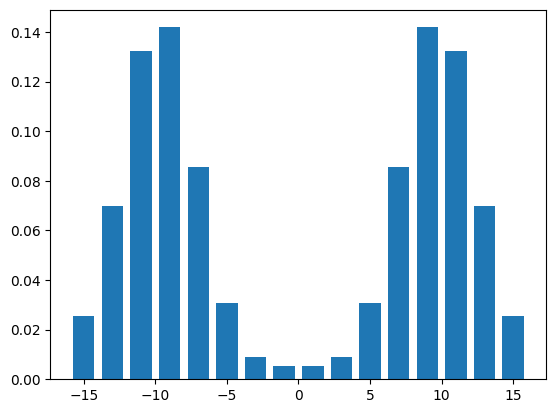

In [9]:
x = np.arange(-15,17,2)
plt.bar(x, rho_q.diag(), width=1.5)

## DV to CV

In [ ]:
for c in range(0,len(cutoff_arr)):
    cutoff = 2**cutoff_arr[c]
    print('CUTOFF: 2**' + str(cutoff_arr[c]) )

    a = destroy(cutoff)
    x = (a + a.dag())/np.sqrt(2)

    # Parameters
    lmbda = 0.29 
    rho_q_recover = basis_trans_U*(rho_q.permute([3,2,1,0]))*basis_trans_U.dag()

    # Initialize starting state
    num_qubits = 4
    sr = np.log(1.12/lmbda)
    qubit_init = rho_q_recover
    osc_init = ket2dm(squeeze(cutoff, sr)*basis(cutoff,0)) 
  
    psi0_dm = tensor([qubit_init] + [osc_init])

    # state transfer unitary
    psi_u = Ust*psi0_dm*Ust.dag()

    rho_u = ptrace(psi_u,[num_qubits]) # trace out qubits
    rho_q_recover = ptrace(psi_u,[0,1,2,3]) # trace out oscillator
    rho_q_recover = (basis_trans_U.dag()*(rho_q_recover)*basis_trans_U).permute([3,2,1,0])

    print("Purity (unitary): " + str((rho_u**2).tr()))

-----------------------
CUTOFF: 2**5
-----------------------
Purity (unitary): 0.7690729439680034


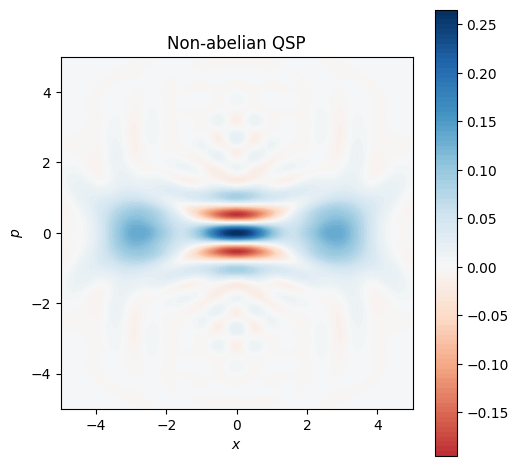

In [12]:
import matplotlib as mpl
from matplotlib import cm

xvec = np.linspace(-5, 5, 300)
yvec = np.linspace(-5, 5, 300)

plt.figure(figsize=(5,5))

W = wigner(rho_u, xvec, yvec)
maxcolor = np.max([np.abs(W.min()), np.abs(W.max())])
nrm = mpl.colors.Normalize(-maxcolor,maxcolor)

plt.contourf(xvec, yvec, W, 100,cmap=cm.RdBu, norm=nrm)
plt.tight_layout()
h = plt.colorbar()
plt.xlabel(r'$x$')
plt.ylabel(r'$p$')
plt.title('Non-abelian QSP')
plt.gca().set_aspect('equal', 'box')